In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

# Define your desired folder path
folder_path = '/content/drive/MyDrive/Colab_Projects/Language-Specific-Neurons'

# Check if the folder exists, if not — create it
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created folder: {folder_path}")
else:
    print("Folder already exists!")

# Move to that directory
os.chdir(folder_path)

# Confirm current working directory
print("Current working directory:", os.getcwd())



Folder already exists!
Current working directory: /content/drive/MyDrive/Colab_Projects/Language-Specific-Neurons


In [3]:
import os
from datasets import load_dataset
from transformers import AutoTokenizer
from huggingface_hub import notebook_login
from tqdm.auto import tqdm

# --- Step 1: Login to Hugging Face ---
# A login box will appear. Paste your Hugging Face access token here.
# Get a token at: https://huggingface.co/settings/tokens
print("Please log in to your Hugging Face account.")
notebook_login()


Please log in to your Hugging Face account.


**Load data**

In [5]:
import os
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm import tqdm

# --- Step 2: Configuration ---
PROJECT_PATH = ""
OUTPUT_DIR = os.path.join(PROJECT_PATH, "data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ✅ Collect ~1 million tokens per language
TARGET_TOKEN_COUNT = 1_000_000
MODEL_NAME = "meta-llama/Llama-3.2-3B"
LANGUAGES = ['en', 'hi']
CONFIG_DATE = '20231101'

print(f"Output directory for text files: {OUTPUT_DIR}")

# --- Step 3: Load the Tokenizer ---
print(f"Loading tokenizer for '{MODEL_NAME}'...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer loaded successfully.")

# --- Step 4: Process each language ---
for lang in LANGUAGES:
    print("\n" + "=" * 60)
    print(f"🌍 Processing language: {lang}")
    print("=" * 60)

    collected_documents = []
    current_token_count = 0

    dataset_config = f"{CONFIG_DATE}.{lang}"
    streaming_dataset = load_dataset(
        'wikimedia/wikipedia',
        dataset_config,
        split='train',
        streaming=True
    )

    pbar = tqdm(desc=f"Tokens for {lang}", total=TARGET_TOKEN_COUNT, unit='tok')

    for doc in streaming_dataset:
        if current_token_count >= TARGET_TOKEN_COUNT:
            break

        text = doc.get('text', '')
        if not text:
            continue

        # ⚡ Optional: truncate very large docs for efficiency
        text = text[:5000]
        num_tokens = len(tokenizer.encode(text, add_special_tokens=False))

        if num_tokens == 0:
            continue

        collected_documents.append(text)
        current_token_count += num_tokens
        pbar.update(num_tokens)

    pbar.close()

    # --- Step 5: Save to file ---
    output_filepath = os.path.join(OUTPUT_DIR, f"wikipedia_1M_{lang}.txt")
    print(f"\n💾 Saving {len(collected_documents)} docs ({current_token_count:,} tokens) to {output_filepath}...")

    with open(output_filepath, 'w', encoding='utf-8') as f:
        f.write("\n\n".join(collected_documents))

    print(f"✅ Successfully saved file for language '{lang}'. ({current_token_count:,} tokens total)")

print("\n🎯 All languages processed successfully with 1M tokens each!")


Output directory for text files: data
Loading tokenizer for 'meta-llama/Llama-3.2-3B'...


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

✅ Tokenizer loaded successfully.

🌍 Processing language: en


...

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Tokens for en: 1000237tok [00:06, 151040.11tok/s]                           



💾 Saving 1002 docs (1,000,237 tokens) to data/wikipedia_1M_en.txt...
✅ Successfully saved file for language 'en'. (1,000,237 tokens total)

🌍 Processing language: hi


Tokens for hi: 1000854tok [00:04, 231446.95tok/s]                           



💾 Saving 564 docs (1,000,854 tokens) to data/wikipedia_1M_hi.txt...
✅ Successfully saved file for language 'hi'. (1,000,854 tokens total)

🎯 All languages processed successfully with 1M tokens each!


**convert tokens into token id's**

In [6]:
import torch
import os
from transformers import AutoTokenizer
from tqdm.auto import tqdm

# --- Configuration ---
PROJECT_PATH = ""
DATA_DIR = os.path.join(PROJECT_PATH, "data")
MODEL_NAME = "meta-llama/Llama-3.2-3B"
LANGUAGES = ['en', 'hi']

print("🔹 Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer loaded successfully.")

# --- Tokenize each 1M-token dataset ---
for lang in LANGUAGES:
    input_filepath = os.path.join(DATA_DIR, f"wikipedia_1M_{lang}.txt")
    output_filepath = os.path.join(DATA_DIR, f"id.{lang}.1M.llama.pt")

    print("\n" + "=" * 70)
    print(f"🌍 Processing language: {lang}")
    print(f"📥 Reading from: {input_filepath}")
    print(f"💾 Saving to: {output_filepath}")
    print("=" * 70)

    if not os.path.exists(input_filepath):
        print(f"❌ ERROR: Input file not found at {input_filepath}")
        continue

    token_ids = []
    total_tokens = 0
    flush_interval = 500_000  # flush every 0.5M tokens

    with open(input_filepath, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc=f"Tokenizing {lang}", unit="line"):
            line = line.strip()
            if not line:
                continue

            # Encode text into token IDs
            ids = tokenizer.encode(line, add_special_tokens=False)
            if not ids:
                continue

            token_ids.extend(ids)
            total_tokens += len(ids)

            # Periodically flush to disk to prevent memory overflow
            if len(token_ids) >= flush_interval:
                torch.save(torch.LongTensor(token_ids), output_filepath)
                print(f"🌀 Flushed {len(token_ids):,} tokens to {output_filepath}")
                token_ids = []

    # --- Save remaining tokens ---
    if token_ids:
        torch.save(torch.LongTensor(token_ids), output_filepath)
        print(f"✅ Final flush: saved {len(token_ids):,} remaining tokens")

    print(f"✅ Token tensor for '{lang}' saved successfully.")
    print(f"📊 Total tokens processed: {total_tokens:,}")

print("\n🎯 All tokenization steps complete for 1M-token datasets!")


🔹 Loading tokenizer...
✅ Tokenizer loaded successfully.

🌍 Processing language: en
📥 Reading from: data/wikipedia_1M_en.txt
💾 Saving to: data/id.en.1M.llama.pt


Tokenizing en: 0line [00:00, ?line/s]

🌀 Flushed 500,048 tokens to data/id.en.1M.llama.pt
✅ Final flush: saved 491,293 remaining tokens
✅ Token tensor for 'en' saved successfully.
📊 Total tokens processed: 991,341

🌍 Processing language: hi
📥 Reading from: data/wikipedia_1M_hi.txt
💾 Saving to: data/id.hi.1M.llama.pt


Tokenizing hi: 0line [00:00, ?line/s]

🌀 Flushed 500,025 tokens to data/id.hi.1M.llama.pt
✅ Final flush: saved 494,521 remaining tokens
✅ Token tensor for 'hi' saved successfully.
📊 Total tokens processed: 994,546

🎯 All tokenization steps complete for 1M-token datasets!


**Divide data into train and validation**

In [7]:
import torch
import os

# --- Configuration ---
DATA_DIR = "data"  # folder containing your original 1M-token files
LANGUAGES = ["en", "hi"]
VALIDATION_RATIO = 0.05  # 5% of tokens for validation

# Loop over each language
for lang in LANGUAGES:
    # Original training file (1M tokens)
    train_path = os.path.join(DATA_DIR, f"id.{lang}.1M.llama.pt")

    if not os.path.exists(train_path):
        print(f"❌ File not found: {train_path}")
        continue

    # Load the full training token tensor
    all_tokens = torch.load(train_path)
    total_tokens = all_tokens.size(0)

    # Compute sizes
    val_size = int(total_tokens * VALIDATION_RATIO)
    train_size = total_tokens - val_size

    # Split tokens into train and validation
    train_tokens = all_tokens[:train_size]
    valid_tokens = all_tokens[train_size:]

    # Save new train and validation files
    train_out = os.path.join(DATA_DIR, f"id.{lang}.train.1M.llama.pt")
    valid_out = os.path.join(DATA_DIR, f"id.{lang}.valid.1M.llama.pt")

    torch.save(train_tokens, train_out)
    torch.save(valid_tokens, valid_out)

    print(f"✅ {lang.upper()} split:")
    print(f"   Train tokens: {train_size} → {train_out}")
    print(f"   Validation tokens: {val_size} → {valid_out}")


✅ EN split:
   Train tokens: 466729 → data/id.en.train.1M.llama.pt
   Validation tokens: 24564 → data/id.en.valid.1M.llama.pt
✅ HI split:
   Train tokens: 469795 → data/id.hi.train.1M.llama.pt
   Validation tokens: 24726 → data/id.hi.valid.1M.llama.pt


**activation.py**

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm
import os

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
MODEL_NAME = "meta-llama/Llama-3.2-3B"
LANGUAGES = ["en", "hi"]
DATA_DIR = "data"
OUTPUT_DIR = "data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 2
MAX_LENGTH = 1024

# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------
print("🔹 Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
).eval()

print("✅ Model loaded.")

num_layers = model.config.num_hidden_layers
intermediate = model.config.intermediate_size
print(f"📊 Layers = {num_layers}, MLP width = {intermediate}")


# --------------------------------------------------
# HOOK FACTORY — Collect squared activations
# --------------------------------------------------
def make_hook(layer_idx, target_tensor):
    def hook(module, input, output):
        x = input[0]                                 # [B, T, H]

        gate = torch.nn.functional.silu(module.gate_proj(x))  # [B, T, I]
        up   = module.up_proj(x)                            # [B, T, I]
        activation = (gate * up).float()                    # [B, T, I]

        # Sum of squared activation → strong signal
        target_tensor[layer_idx] += (activation ** 2).sum(dim=(0, 1))
    return hook


# --------------------------------------------------
# MAIN LOOP OVER LANGUAGES
# --------------------------------------------------
for lang in LANGUAGES:
    print(f"\n🌍 Processing language = {lang}")

    file_path = os.path.join(DATA_DIR, f"id.{lang}.train.1M.llama.pt")
    if not os.path.exists(file_path):
        print(f"❌ Missing tokens: {file_path}")
        continue

    # Load tokens
    tokens = torch.load(file_path).to("cuda")
    total_tokens = tokens.size(0)
    print(f"📥 Loaded {total_tokens:,} tokens.")

    # Storage tensor for this language
    # shape: [num_layers, intermediate]
    activation_strength = torch.zeros(
        num_layers, intermediate, dtype=torch.float32, device="cuda"
    )

    # Register hooks
    hooks = []
    for i, layer in enumerate(model.model.layers):
        hook = layer.mlp.register_forward_hook(make_hook(i, activation_strength))
        hooks.append(hook)

    # Process in batches
    for start in tqdm(range(0, total_tokens, BATCH_SIZE * MAX_LENGTH), desc=lang):
        chunks = []

        for b in range(BATCH_SIZE):
            s = start + b * MAX_LENGTH
            if s >= total_tokens:
                break

            e = min(s + MAX_LENGTH, total_tokens)
            chunk = tokens[s:e]

            if chunk.size(0) < MAX_LENGTH:
                pad = torch.zeros(MAX_LENGTH - chunk.size(0),
                                   dtype=chunk.dtype, device="cuda")
                chunk = torch.cat([chunk, pad])

            chunks.append(chunk)

        if not chunks:
            continue

        batch = torch.stack(chunks, dim=0)
        attn = (batch != 0).long()

        with torch.no_grad():
            _ = model(input_ids=batch, attention_mask=attn)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Save results
    save_path = os.path.join(OUTPUT_DIR, f"activation.{lang}.train.1M.llama32.pt")
    torch.save(
        {
            "activation_strength": activation_strength.cpu(),
            "total_tokens": total_tokens
        },
        save_path
    )

    print(f"💾 Saved: {save_path}")

print("\n🎯 Completed activation collection!")


🔹 Loading model...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Model loaded.
📊 Layers = 28, MLP width = 8192

🌍 Processing language = en
📥 Loaded 466,729 tokens.


en:   0%|          | 0/228 [00:00<?, ?it/s]

💾 Saved: data/activation.en.train.1M.llama32.pt

🌍 Processing language = hi
📥 Loaded 469,795 tokens.


hi:   0%|          | 0/230 [00:00<?, ?it/s]

💾 Saved: data/activation.hi.train.1M.llama32.pt

🎯 Completed activation collection!


**identify.py**

In [5]:
import torch
import os

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
LANGS = ['en', 'hi']
DATA_DIR = "data"
OUT_DIR = "activation_mask"
os.makedirs(OUT_DIR, exist_ok=True)

ACT_FILE = "activation.{lang}.train.1M.llama32.pt"

# % of neurons to consider (top-K by specialization)
TOP_RATE = 0.01      # top 1%
STRENGTH_RATIO = 0.90   # strength filter
ENTROPY_LARGEST = False # want *lowest* entropy


# --------------------------------------------------
# LOAD ACTIVATION DATA
# --------------------------------------------------
print("📥 Loading per-language activation tensors...")

activation_list = []
token_count_list = []

for lang in LANGS:
    path = os.path.join(DATA_DIR, ACT_FILE.format(lang=lang))

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    data = torch.load(path)

    act = data["activation_strength"]       # [L, I]
    total = data["total_tokens"]

    activation_list.append(act)
    token_count_list.append(total)

# stack → [K, L, I]
activation = torch.stack(activation_list, dim=0).float()   # [K, L, I]
token_counts = torch.tensor(token_count_list).float()       # [K]

lang_num, num_layers, intermediate_size = activation.shape

print(f"📊 Loaded activations: {lang_num} languages, {num_layers} layers, {intermediate_size} neurons.")


# --------------------------------------------------
# NORMALIZE PER LANGUAGE
# --------------------------------------------------
# activation_per_token: [K, L, I]
activation_per_token = activation / token_counts.view(-1, 1, 1)

# move lang dimension to the end → [L, I, K]
act_LIK = activation_per_token.permute(1, 2, 0)


# --------------------------------------------------
# COMPUTE SPECIALIZATION METRIC
# --------------------------------------------------
# Normalize activation across languages for each neuron
distribution = act_LIK / (act_LIK.sum(dim=-1, keepdim=True) + 1e-12)

# Shannon entropy → lowest entropy = most language-special
entropy = -(distribution * (distribution + 1e-12).log()).sum(dim=-1)   # [L, I]


# --------------------------------------------------
# FILTER BY ACTIVATION STRENGTH
# --------------------------------------------------
flat_vals = act_LIK.flatten()
strength_threshold = flat_vals.kthvalue(int(len(flat_vals) * STRENGTH_RATIO)).values.item()

strong_mask = (act_LIK > strength_threshold).sum(dim=-1)    # [L, I]

# neurons never strongly activated by any language are useless
entropy[strong_mask == 0] = float("inf")


# --------------------------------------------------
# SELECT TOP-K MOST SPECIALIZED NEURONS
# --------------------------------------------------
flat_entropy = entropy.flatten()
top_k = int(len(flat_entropy) * TOP_RATE)

values, indices = flat_entropy.topk(top_k, largest=ENTROPY_LARGEST)

rows = indices // intermediate_size
cols = indices % intermediate_size

# selected activations for these neurons → [N, K]
selected = act_LIK[rows, cols]

# assign each neuron to language with strongest activation
winners = selected.argmax(dim=-1)   # [N]

print("\n🔍 Language distribution among selected neurons:")
for i, lang in enumerate(LANGS):
    print(f"  {lang}: {(winners == i).sum().item()} neurons")


# --------------------------------------------------
# BUILD MASKS (PER-LANGUAGE → PER-LAYER → LIST OF NEURONS)
# --------------------------------------------------
final_masks = [[] for _ in range(lang_num)]

for i, lang in enumerate(LANGS):
    final_masks[i] = [[] for _ in range(num_layers)]

selected_rows = rows   # layer index
selected_cols = cols   # neuron index

for neuron_idx in range(top_k):
    lang_id = winners[neuron_idx].item()
    layer = selected_rows[neuron_idx].item()
    neuron = selected_cols[neuron_idx].item()
    final_masks[lang_id][layer].append(neuron)

# Convert to tensors
for k in range(lang_num):
    for layer in range(num_layers):
        lst = final_masks[k][layer]
        final_masks[k][layer] = torch.tensor(lst, dtype=torch.long)


# --------------------------------------------------
# SAVE MASK FILE
# --------------------------------------------------
save_path = os.path.join(OUT_DIR, "llama32_activation_masks.pt")
torch.save(final_masks, save_path)

print(f"\n💾 Saved final masks → {save_path}")
print("🎯 Neuron selection complete.")


📥 Loading per-language activation tensors...
📊 Loaded activations: 2 languages, 28 layers, 8192 neurons.

🔍 Language distribution among selected neurons:
  en: 570 neurons
  hi: 1723 neurons

💾 Saved final masks → activation_mask/llama32_activation_masks.pt
🎯 Neuron selection complete.


**Print the neurons**

In [6]:
import torch
import os

# --- Configuration ---
output_dir = 'activation_mask'
languages = ['en', 'hi'] # This list should match the order in which masks were saved

# Load the single combined mask file
combined_masks_path = os.path.join(output_dir, 'llama32_activation_masks.pt')
if not os.path.exists(combined_masks_path):
    print(f"❌ Error: Combined activation mask file not found at {combined_masks_path}")
else:
    all_language_layer_masks = torch.load(combined_masks_path)

    for i, lang in enumerate(languages):
        # Access the masks for the current language
        layer_masks = all_language_layer_masks[i]

        print(f"\n--- Activation mask for {lang.upper()} ---")
        print("layer-wise neuron indices = [")

        for j, neuron_tensor in enumerate(layer_masks):
            print(f"    layer {j}: tensor({neuron_tensor.tolist()})")

        print("]\n")


--- Activation mask for EN ---
layer-wise neuron indices = [
    layer 0: tensor([2503, 8004])
    layer 1: tensor([])
    layer 2: tensor([3840, 5187])
    layer 3: tensor([4092])
    layer 4: tensor([6029, 7367, 7001, 3443, 3432])
    layer 5: tensor([3849, 2994])
    layer 6: tensor([])
    layer 7: tensor([4634])
    layer 8: tensor([])
    layer 9: tensor([2624])
    layer 10: tensor([])
    layer 11: tensor([])
    layer 12: tensor([6135])
    layer 13: tensor([6049, 141, 8155, 5187])
    layer 14: tensor([7102, 6425, 3858, 1984, 560, 2892, 3305, 7209, 2175])
    layer 15: tensor([3220, 1647, 7013, 2491, 3454, 4284, 2665, 2490, 4026, 6233, 6569, 4243, 2285, 4010, 1094, 5947])
    layer 16: tensor([7887, 2376, 3618, 2941, 678, 1511, 4350, 32, 5050, 2413, 6030, 1443, 4704, 4469, 7905, 6602, 3936, 7562, 5857, 3815, 1355, 5464, 2309, 7048])
    layer 17: tensor([1941, 1117, 6017, 6568, 4391, 2414, 3409, 5721, 4455, 6507, 6122, 4990, 2361, 724, 743, 890, 3324, 8024, 1115, 5435, 5275,

**ppl.py**

In [7]:
import argparse
from types import MethodType
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
from glob import glob
import math

# Get current working directory to construct absolute paths
current_working_dir = os.getcwd()

parser = argparse.ArgumentParser(description="Evaluate LLaMA model with language-specific activation masks.")
parser.add_argument("-m","--model",type=str,default="meta-llama/Llama-3.2-3B")
parser.add_argument("-d","--data_dir",type=str,default=os.path.join(current_working_dir, "data"))
parser.add_argument("-a","--activation_mask_dir",type=str,default=os.path.join(current_working_dir, "activation_mask"))
parser.add_argument("--batch_size",type=int,default=1)
args, unknown = parser.parse_known_args()
if unknown:
    print(f"Ignoring unknown arguments: {unknown}")

print("🔹 Loading model & tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args.model)
model = AutoModelForCausalLM.from_pretrained(
    args.model, torch_dtype=torch.float16, device_map="auto"
).eval()
print("✅ Model loaded.")

num_layers = model.config.num_hidden_layers
intermediate = model.config.intermediate_size
max_length = min(getattr(model.config, "max_position_embeddings", 4096), 1024)

print(f"📊 Model: {num_layers} layers | width {intermediate} | max eval length {max_length}")

# ---------------------------------------------------------
# DETECT LANGUAGES BASED ON AVAILABLE FILES
# ---------------------------------------------------------
print(f"DEBUG: Looking for data files in: {args.data_dir}")
# Add a debug line to list contents of data_dir
print(f"!ls -l {args.data_dir}")
!ls -l {args.data_dir}

valid_files = sorted(glob(os.path.join(args.data_dir, "id.*.valid.1M.llama.pt")))
if not valid_files:
    print("⚠️ No valid.* files found. Using train.* files.")
    valid_files = sorted(glob(os.path.join(args.data_dir, "id.*.train.1M.llama.pt")))

if not valid_files:
    raise FileNotFoundError("❌ No dataset files found in data_dir!")

languages = []
for p in valid_files:
    parts = os.path.basename(p).split(".")
    languages.append(parts[1])

languages = list(dict.fromkeys(languages))
print("🌍 Detected languages:", languages)

# ---------------------------------------------------------
# LOAD COMBINED MASK FILE
# ---------------------------------------------------------
mask_path = os.path.join(args.activation_mask_dir, "llama32_activation_masks.pt")
if not os.path.exists(mask_path):
    raise FileNotFoundError(f"❌ Activation mask file missing: {mask_path}")

print("\n🔹 Loading activation masks...")
all_language_masks = torch.load(mask_path)
assert len(all_language_masks) == len(languages)
print("✅ Loaded mask for", len(languages), "languages")

# ---------------------------------------------------------
# FACTORY FOR MASKED FORWARD PASS
# ---------------------------------------------------------
def factory(mask_idx):
    def new_forward(self, x):
        gate = self.gate_proj(x)
        up = self.up_proj(x)
        act = torch.nn.functional.silu(gate) * up
        if mask_idx is not None and mask_idx.numel():
            act.index_fill_(2, mask_idx.to(x.device), 0)
        return self.down_proj(act)
    return new_forward

# Save original forwards
orig_forwards = [layer.mlp.forward for layer in model.model.layers]

def restore():
    for layer, fwd in zip(model.model.layers, orig_forwards):
        layer.mlp.forward = fwd

# ---------------------------------------------------------
# PER-LANGUAGE PPL EVALUATION
# ---------------------------------------------------------
@torch.no_grad()
def evaluate(lang, bs):
    file = os.path.join(args.data_dir, f"id.{lang}.valid.1M.llama.pt")
    if not os.path.exists(file):
        file = os.path.join(args.data_dir, f"id.{lang}.train.1M.llama.pt")

    if not os.path.exists(file):
        print(f"❌ Missing text dataset for {lang} at {file}") # Added debug line
        return float("nan")

    ids = torch.load(file).to(model.device)
    N = (ids.size(0) // max_length) * max_length
    if N == 0:
        return float("nan")

    ids = ids[:N].view(-1, max_length)

    losses = []
    for i in range(0, ids.size(0), bs):
        batch = ids[i:i+bs]
        attn = torch.ones_like(batch)
        out = model(input_ids=batch, attention_mask=attn, labels=batch)
        losses.append(out.loss.item())

    nll = float(np.mean(losses))
    ppl = math.exp(nll)
    return ppl

# ---------------------------------------------------------
# BASELINE (NO MASK)
# ---------------------------------------------------------
print("\n🚀 Baseline evaluation (no masking)")
restore()
baseline = [evaluate(l, args.batch_size) for l in languages]

# ---------------------------------------------------------
# APPLY MASKS & EVALUATE
# ---------------------------------------------------------
results = []
for lang_id, mask_lang in enumerate(languages):
    print(f"\n🔧 Applying mask for language: {mask_lang.upper()}")
    restore()
    layer_masks = all_language_masks[lang_id]

    for i, layer in enumerate(model.model.layers):
        idx = layer_masks[i]
        layer.mlp.forward = MethodType(factory(idx), layer.mlp)

    masked_scores = [evaluate(l, args.batch_size) for l in languages]
    results.append((mask_lang, masked_scores))

# ---------------------------------------------------------
# PRINT RESULTS TABLE
# ---------------------------------------------------------
print("\n📊 Perplexity Table (lower = better)")
header = "MASK | " + " | ".join([f"{l.upper():>8}" for l in languages])
print(header)
print("-" * len(header))

row = f"{'BASELINE':>4} | " + " | ".join([f"{p:.2f}" for p in baseline])
print(row)

for mask_lang, vals in results:
    row = f"{mask_lang.upper():>4} | " + " | ".join([f"{p:.2f}" for p in vals])
    print(row)

print("\n✅ Done.")

Ignoring unknown arguments: ['-f', '/root/.local/share/jupyter/runtime/kernel-3f7eb790-9d0b-4383-af71-28049addaefc.json']
🔹 Loading model & tokenizer...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Model loaded.
📊 Model: 28 layers | width 8192 | max eval length 1024
DEBUG: Looking for data files in: /content/drive/MyDrive/Colab_Projects/Language-Specific-Neurons/data
!ls -l /content/drive/MyDrive/Colab_Projects/Language-Specific-Neurons/data
total 34075
-rw------- 1 root root  919370 Nov 15 09:33 activation.en.train.1M.llama32.pt
-rw------- 1 root root  919370 Nov 15 09:38 activation.hi.train.1M.llama32.pt
-rw------- 1 root root 3931930 Nov 15 09:21 id.en.1M.llama.pt
-rw------- 1 root root 3931972 Nov 15 09:21 id.en.train.1M.llama.pt
-rw------- 1 root root 3931972 Nov 15 09:21 id.en.valid.1M.llama.pt
-rw------- 1 root root 3957786 Nov 15 09:21 id.hi.1M.llama.pt
-rw------- 1 root root 3957828 Nov 15 09:21 id.hi.train.1M.llama.pt
-rw------- 1 root root 3957828 Nov 15 09:21 id.hi.valid.1M.llama.pt
-rw------- 1 root root 4501577 Nov 15 09:21 wikipedia_1M_en.txt
-rw------- 1 root root 4880023 Nov 15 09:21 wikipedia_1M_hi.txt
🌍 Detected languages: ['en', 'hi']

🔹 Loading activation m

**Plotting heatmap**

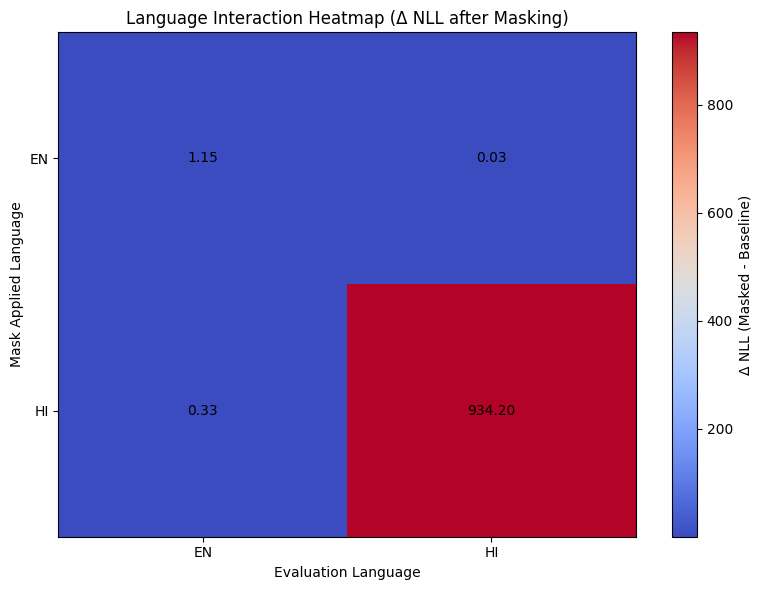

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# Prepare data
# -------------------------------------
baseline_arr = np.array(baseline)  # shape: [num_langs]

mask_langs = [m for (m, _) in results]
masked_matrix = np.array([vals for (_, vals) in results])  # shape: [num_masks, num_langs]

# difference = masked - baseline
diff_matrix = masked_matrix - baseline_arr  # broadcasted subtraction

# -------------------------------------
# Plot heatmap
# -------------------------------------
plt.figure(figsize=(8, 6))
plt.imshow(diff_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Δ NLL (Masked - Baseline)")

plt.xticks(range(len(languages)), [l.upper() for l in languages])
plt.yticks(range(len(mask_langs)), [m.upper() for m in mask_langs])

plt.title("Language Interaction Heatmap (Δ NLL after Masking)")
plt.xlabel("Evaluation Language")
plt.ylabel("Mask Applied Language")

# Annotate each cell with numeric values
for i in range(diff_matrix.shape[0]):
    for j in range(diff_matrix.shape[1]):
        val = diff_matrix[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


**Neuron activation and deactivation**

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from types import MethodType
import os

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
MODEL = "meta-llama/Llama-3.2-3B"
MASK_FILE = "activation_mask/llama32_activation_masks.pt"

EN_ID = 0   # English mask ID (example)
HI_ID = 1   # Hindi mask ID

print("Loading tokenizer & model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=torch.float16, device_map="auto"
).eval()

num_layers = model.config.num_hidden_layers

# ---------------------------------------------------------
# Load masks
# ---------------------------------------------------------
print("Loading masks...")
all_masks = torch.load(MASK_FILE)

en_masks = all_masks[EN_ID]   # list of tensors per layer
hi_masks = all_masks[HI_ID]   # list of tensors per layer


# ---------------------------------------------------------
# Steering function (English OFF, Hindi ON)
# ---------------------------------------------------------
def steering_factory(en_idx, hi_idx):
    def new_forward(self, x):
        gate = self.gate_proj(x)
        up   = self.up_proj(x)
        act  = torch.nn.functional.silu(gate) * up

        # 1️⃣ Deactivate English neurons
        if en_idx is not None and en_idx.numel() > 0:
            act.index_fill_(2, en_idx.to(x.device), 0)

        # 2️⃣ Boost Hindi neurons
        if hi_idx is not None and hi_idx.numel() > 0:
            act[:, :, hi_idx] = act[:, :, hi_idx] * 1.5

        return self.down_proj(act)

    return new_forward


# ---------------------------------------------------------
# Generation function
# ---------------------------------------------------------
def generate(prompt, custom_model):
    inputs = tokenizer(prompt, return_tensors="pt").to(custom_model.device)
    output = custom_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.9,
        top_p=0.9
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)


# ---------------------------------------------------------
# 1) NORMAL MODEL (NO NEURON EDITING)
# ---------------------------------------------------------
print("\n🔵 Creating copy of model for baseline output...")
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=torch.float16, device_map="auto"
).eval()

# ---------------------------------------------------------
# 2) EDITED MODEL (English OFF, Hindi ON)
# ---------------------------------------------------------
print("🟣 Applying neuron steering (EN OFF, HI ON)...")

edited_model = model  # rename for clarity

for layer_idx, layer in enumerate(edited_model.model.layers):
    en_idx = en_masks[layer_idx]
    hi_idx = hi_masks[layer_idx]

    layer.mlp.forward = MethodType(steering_factory(en_idx, hi_idx), layer.mlp)


# ---------------------------------------------------------
# RUN BOTH MODELS
# ---------------------------------------------------------
english_text = "Hello, how are you? Tell me something interesting."

print("\n🟦 INPUT (English):")
print(english_text)

# Normal output
print("\n🟢 NORMAL OUTPUT (no activation editing):")
normal_out = generate(english_text, baseline_model)
print(normal_out)

# Edited output
print("\n🔴 EDITED OUTPUT (English neurons OFF, Hindi neurons ON):")
edited_out = generate(english_text, edited_model)
print(edited_out)


Loading tokenizer & model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading masks...

🔵 Creating copy of model for baseline output...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


🟣 Applying neuron steering (EN OFF, HI ON)...

🟦 INPUT (English):
Hello, how are you? Tell me something interesting.

🟢 NORMAL OUTPUT (no activation editing):


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Hello, how are you? Tell me something interesting. I like it!
I want to say thank you for your kindness. I like your blog very much!

🔴 EDITED OUTPUT (English neurons OFF, Hindi neurons ON):
Hello, how are you? Tell me something interesting. Are you a fan of the movie? What’s your favorite scene? Do you want to know the ending of the movie? If so, then you are on the right page. Today we will know the ending of the movie, which is also the most important part of the movie. So that you can know the ending of the movie. To get to know the ending of the movie, you have to read the complete article, which is written by us. To know the ending of the movie,


In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from types import MethodType
import os

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
MODEL = "meta-llama/Llama-3.2-3B"
MASK_FILE = "activation_mask/llama32_activation_masks.pt"

EN_ID = 0   # English neuron mask ID
HI_ID = 1   # Hindi neuron mask ID

print("Loading tokenizer & model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=torch.float16, device_map="auto"
).eval()

num_layers = model.config.num_hidden_layers

# ---------------------------------------------------------
# Load neuron masks
# ---------------------------------------------------------
print("Loading masks...")
all_masks = torch.load(MASK_FILE)

en_masks = all_masks[EN_ID]
hi_masks = all_masks[HI_ID]


# ---------------------------------------------------------
# Steering function (Hindi OFF, English ON)
# ---------------------------------------------------------
def steering_factory(hi_idx, en_idx):
    def new_forward(self, x):
        gate = self.gate_proj(x)
        up   = self.up_proj(x)
        act  = torch.nn.functional.silu(gate) * up

        # 1️⃣ Deactivate Hindi neurons
        if hi_idx is not None and hi_idx.numel() > 0:
            act.index_fill_(2, hi_idx.to(x.device), 0)

        # 2️⃣ Boost English neurons
        if en_idx is not None and en_idx.numel() > 0:
            act[:, :, en_idx] = act[:, :, en_idx] * 1.5

        return self.down_proj(act)

    return new_forward


# ---------------------------------------------------------
# Generation function
# ---------------------------------------------------------
def generate(prompt, custom_model):
    inputs = tokenizer(prompt, return_tensors="pt").to(custom_model.device)
    output = custom_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.9,
        top_p=0.9
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)


# ---------------------------------------------------------
# 1) NORMAL MODEL (NO NEURON EDITING)
# ---------------------------------------------------------
print("\n🔵 Creating baseline model for comparison...")
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=torch.float16, device_map="auto"
).eval()


# ---------------------------------------------------------
# 2) EDITED MODEL (Hindi OFF, English ON)
# ---------------------------------------------------------
print("🟣 Applying neuron steering (HI OFF, EN ON)...")

edited_model = model  # reuse the loaded model

for layer_idx, layer in enumerate(edited_model.model.layers):
    hi_idx = hi_masks[layer_idx]
    en_idx = en_masks[layer_idx]

    layer.mlp.forward = MethodType(steering_factory(hi_idx, en_idx), layer.mlp)


# ---------------------------------------------------------
# RUN BOTH MODELS
# ---------------------------------------------------------
hindi_text = "नमस्ते, आप कैसे हैं? कृपया मुझे कुछ रोचक बताइए।"

print("\n🟪 INPUT (Hindi):")
print(hindi_text)

# Normal output
print("\n🟢 NORMAL OUTPUT (no activation editing):")
normal_out = generate(hindi_text, baseline_model)
print(normal_out)

# Edited output
print("\n🔴 EDITED OUTPUT (Hindi neurons OFF, English neurons ON):")
edited_out = generate(hindi_text, edited_model)
print(edited_out)


Loading tokenizer & model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading masks...

🔵 Creating baseline model for comparison...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


🟣 Applying neuron steering (HI OFF, EN ON)...

🟪 INPUT (Hindi):
नमस्ते, आप कैसे हैं? कृपया मुझे कुछ रोचक बताइए।

🟢 NORMAL OUTPUT (no activation editing):


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


नमस्ते, आप कैसे हैं? कृपया मुझे कुछ रोचक बताइए। या फिर मैं आपके बारे में कुछ बताऊँगा। अपने दोस्तों के साथ एक समय के बारे में सोचिएँ जो आपके लिए कितना अच्छा था। मैं उस समय के बारे में सोच रहा हूँ जब मैं अपने दोस्तों से मिला करता था और मुझे उस समय का

🔴 EDITED OUTPUT (Hindi neurons OFF, English neurons ON):
नमस्ते, आप कैसे हैं? कृपया मुझे कुछ रोचक बताइए।  What are you doing?
My name is Ahmed and I’m a photographer based in Amsterdam. I started taking pictures around 2011 when I had a lot of time during my studies. Since then I’ve been shooting for clients as well as friends and people on the streets of Amsterdam. I’ve also had several exhibitions.
I like to document the everyday scenes of Amsterdam. I’m mostly interested in capturing those quiet moments where a person is alone in a street or park. I


**Generate.py**

In [6]:
# List of prompts
prompts = [
    "How can I improve my time management skills?",
    "What are the most effective ways to deal with stress?",
    "What are the main differences between Python and JavaScript programming languages?",
    "How can I increase my productivity while working from home?",
    "Can you explain the basics of quantum computing?",
    "What are the differences between plant-based and animal-based protein sources?",
    "How can I develop my critical thinking skills?",
    "What are the major challenges faced by the education sector today?",
    "What are the primary factors that influence consumer behavior?",
    "What are the most effective strategies for conflict resolution in the workplace?",
    "What are some potential implications of using a single-use plastic bottle versus a reusable bottle on both the environment and human health?",
    "What factors would you consider when designing an inclusive and accessible public transportation system?",
    "How can governments utilize fiscal and monetary policies to combat economic recessions?",
    "How do language and cultural barriers affect the way people communicate and form relationships in multicultural societies?",
    "Describe a scenario where artificial intelligence could be used to improve the quality and efficiency of healthcare delivery.",
    "Explain the process of gene editing using CRISPR-Cas9 technology, and discuss its potential applications and ethical implications.",
    "How do vaccinations work to protect individuals and communities from infectious diseases, and what is herd immunity?",
    "How do social media platforms influence the way people consume and share news, and what are the potential implications for the spread of misinformation?",
    "How do cultural, social, and economic factors influence people's food choices, and how can this knowledge be used to promote healthier diets?",
    "Explain the process of natural selection and how it contributes to the evolution and adaptation of species.",
    "How would you introduce yourself as a medieval knight at a royal banquet?",
    "As a pirate captain, what would you say to your crew to motivate them to search for hidden treasure?",
    "If you were a Shakespearean character, how would you declare your love for someone in a soliloquy?",
    "As a superhero, how would you explain your origin story to a curious child?",
    "Imagine you are a time traveler from the year 3000. What technological advancements would you tell people about?",
    "As a sports commentator, describe the winning play in the final seconds of a championship game.",
    "Pretend to be a world-famous chef. How would you describe your signature dish to a panel of judges?",
    "You are a mountain climber reaching the summit of Mount Everest. Describe your emotions and the view from the top.",
    "As a space colonist on Mars, describe your daily life and the challenges you face living on another planet.",
    "Pretend to be a character in a post-apocalyptic world. Describe how you survive and the allies you encounter.",
    "How can you determine if a restaurant is popular among locals or mainly attracts tourists, and why might this information be useful?",
    "What are some subtle clues that suggest someone is pretending to understand a topic or conversation when they are actually confused or uninformed?",
    "Why might someone choose to use a paper map or ask for directions instead of relying on a GPS device or smartphone app?",
    "How can you determine if a person is genuinely interested in a conversation or simply being polite?",
    "Why might someone prefer to shop at a small, locally-owned business instead of a large chain store, even if the prices are higher?",
    "How can you assess the credibility of a source of information, such as a news article or blog post, without relying solely on the reputation of the author or publisher?",
    "Why do some people enjoy the sensation of being scared, such as by watching horror movies or going on roller coasters, while others avoid these experiences?",
    "How can observing the behavior of other people in a social situation provide clues about cultural norms and expectations?",
    "Do we have a moral obligation to explore space, or should we focus on solving Earth's problems first?",
    "In a world where automation is becoming increasingly prevalent, is it more important to prioritize job creation or technological progress?",
    "How many times does the average human blink in a lifetime? Try to explain your answer step-by-step.",
    "How many atoms are in a grain of salt? Try to explain your answer step-by-step.",
    "How many lightning strikes occur on Earth each day? Try to explain your answer step-by-step.",
    "How many balloons would it take to lift a house like in the movie 'Up'? Try to explain your answer step-by-step.",
    "How many text messages are sent globally in a minute? Try to explain your answer step-by-step.",
    "How many words are spoken daily on Earth? Try to explain your answer step-by-step.",
    "How many snowflakes fall during a typical winter? Try to explain your answer step-by-step.",
    "How many pages are in all the books ever written? Try to explain your answer step-by-step.",
    "How many times has the Earth orbited the Sun since the beginning of life? Try to explain your answer step-by-step.",
    "How many songs have been recorded throughout history? Try to explain your answer step-by-step.",
    "What if the Internet had been invented during the Renaissance period?",
    "What if the Aztecs had successfully repelled the Spanish conquistadors?",
    "What if the Black Death had not occurred in the 14th century?",
    "What if Isaac Newton had focused on biology instead of physics?",
    "What if the Beatles had never formed as a band?",
    "What if Alan Turing had not cracked the Enigma code during World War II?",
    "What if the Suez Canal had never been constructed?",
    "What if the Maya civilization had never mysteriously collapsed?",
    "What if Christopher Columbus had not discovered the Americas?",
    "What if Vincent van Gogh had been a successful artist during his lifetime?",
    "Can you help me write a formal email to a potential business partner proposing a joint venture?",
    "Can you help me write a resignation letter to my current employer, while leaving on good terms and expressing gratitude for the opportunities provided?",
    "Use an appropriate format to structure a formal letter of recommendation for a student applying to a prestigious graduate program in computer science.",
    "Write a compelling product launch announcement email to inform our customers of our new software solution.",
    "Draft an apology email to a customer who experienced a delay in their order, and provide reassurance that the issue has been resolved.",
    "Write a script for a YouTube video exploring the history and cultural significance of jazz.",
    "Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.",
    "Write a captivating movie review for a recently released science fiction film, discussing its plot, characters, and special effects.",
    "Structure a podcast script for an episode discussing the influence of streaming platforms on the music industry.",
    "Write a symphony concert review, discussing the orchestra's performance and overall audience experience."
]

# Create directory if it doesn't exist
os.makedirs("dataset/mvicuna", exist_ok=True)

# Write prompts to en.txt
with open("dataset/mvicuna/en.txt", "w", encoding="utf-8") as f:
    for prompt in prompts:
        f.write(prompt + "\n")

print("✅ Saved prompts to dataset/mvicuna/en.txt")


✅ Saved prompts to dataset/mvicuna/en.txt


In [7]:
hi_prompts = [
    # Self-improvement
    "मैं अपने समय प्रबंधन कौशल को कैसे सुधार सकता हूँ?",
    "तनाव से निपटने के सबसे प्रभावी तरीके क्या हैं?",
    "मैं अपनी आलोचनात्मक सोच कौशल कैसे विकसित कर सकता हूँ?",
    "घर से काम करते समय अपनी उत्पादकता कैसे बढ़ा सकता हूँ?",
    "सकारात्मक आदतें विकसित करने के लिए क्या कदम उठाए जा सकते हैं?",

    # Science & Technology
    "क्वांटम कंप्यूटिंग की मूल बातें समझाइए।",
    "CRISPR-Cas9 तकनीक के माध्यम से जीन संपादन की प्रक्रिया बताइए।",
    "वैक्सीन कैसे काम करती हैं और हर्ड इम्युनिटी क्या है?",
    "प्लास्टिक की एकल-उपयोग वाली बोतल और पुन: प्रयोज्य बोतल का पर्यावरण और स्वास्थ्य पर क्या प्रभाव पड़ता है?",
    "Python और JavaScript प्रोग्रामिंग भाषाओं के मुख्य अंतर क्या हैं?",

    # Daily life & practical scenarios
    "घर से काम करते समय समय और ऊर्जा का प्रबंधन कैसे करें?",
    "सामाजिक स्थितियों में दूसरों के व्यवहार को देखकर सांस्कृतिक नियम कैसे समझे जा सकते हैं?",
    "एक रेस्टोरेंट की लोकप्रियता को कैसे परखा जा सकता है?",
    "किसी स्रोत की विश्वसनीयता का मूल्यांकन कैसे किया जाए?",
    "व्यक्तिगत और व्यावसायिक जीवन में ध्यान और फोकस कैसे बनाए रखें?",

    # Imaginative & creative scenarios
    "एक समुद्री डाकू कप्तान के रूप में अपने क्रू को खजाना खोजने के लिए कैसे प्रोत्साहित करेंगे?",
    "यदि आप एक सुपरहीरो हों, तो अपने उत्पत्ति की कहानी कैसे बताएंगे?",
    "कल्पना कीजिए कि आप वर्ष 3000 से समय यात्री हैं। लोगों को किन तकनीकी विकासों के बारे में बताएंगे?",
    "एक अंतरिक्ष उपनिवेशकर्ता के रूप में मंगल पर अपने दैनिक जीवन और चुनौतियों का वर्णन कीजिए।",
    "पोस्ट-एपोकैलिप्टिक दुनिया में एक पात्र के रूप में अपने उत्तरजीविता कौशल का वर्णन करें।",

    # History & what-if scenarios
    "यदि ब्लैक डेथ 14वीं सदी में नहीं हुआ होता तो क्या होता?",
    "अगर बीटल्स कभी एक बैंड के रूप में नहीं बने होते तो संगीत उद्योग पर क्या प्रभाव पड़ता?",
    "यदि क्रिस्टोफर कोलंबस ने अमेरिका की खोज नहीं की होती तो इतिहास कैसे बदलता?",
    "यदि माया सभ्यता अचानक ढह न जाती तो क्या होता?",
    "यदि न्यूटन ने भौतिकी के बजाय जीवविज्ञान पर ध्यान केंद्रित किया होता तो क्या होता?",

    # Science & estimation questions
    "एक मानक वर्ष में पृथ्वी पर कितने बिजली गिरते हैं?",
    "एक साल में मानव शरीर में औसतन कितनी बार पलक झपकते हैं?",
    "एक ग्रेन नमक में कितने परमाणु होते हैं? इसका अनुमान बताइए।",
    "एक मिनट में दुनिया भर में कितने टेक्स्ट संदेश भेजे जाते हैं?",
    "पृथ्वी पर प्रतिदिन कितने शब्द बोले जाते हैं? इसका अनुमान लगाइए।",

    # Practical writing tasks
    "एक व्यवसायिक सहयोग के लिए औपचारिक ईमेल कैसे लिखा जाए?",
    "ग्राहक को देर हुए आदेश के लिए माफी का पत्र कैसे लिखा जाए?",
    "कंप्यूटर विज्ञान में स्नातक छात्र के लिए सिफारिश पत्र कैसे लिखा जाए?",
    "नई सॉफ़्टवेयर सुविधा की घोषणा के लिए आकर्षक ईमेल कैसे लिखा जाए?",
    "यूट्यूब वीडियो के लिए स्क्रिप्ट कैसे तैयार की जाए जो इतिहास और सांस्कृतिक महत्व पर हो?",

    # Food & lifestyle
    "सांस्कृतिक, सामाजिक और आर्थिक कारक लोगों की भोजन पसंद को कैसे प्रभावित करते हैं?",
    "शाकाहारी और मांसाहारी प्रोटीन स्रोतों के बीच मुख्य अंतर क्या हैं?",
    "स्वस्थ आहार को बढ़ावा देने के लिए लोगों के भोजन चुनाव का विश्लेषण कैसे किया जाए?",
    "आप किसी रेस्तरां में अपने अनुभव और व्यंजन का वर्णन कैसे करेंगे?",
    "स्थानीय बाजार में खरीदारी करने के क्या फायदे हैं, और लोग इसे क्यों चुनते हैं?",

    # Miscellaneous fun & curiosity
    "यदि आप मध्यकालीन शूरवीर होते, तो शाही भोज में खुद को कैसे पेश करते?",
    "यदि आप शेक्सपियरियन पात्र होते, तो किसी से प्रेम कैसे घोषित करते?",
    "यदि आप प्रसिद्ध शेफ होते, तो अपनी खास डिश का वर्णन कैसे करते?",
    "यदि आप समय यात्री होते, तो प्राचीन सभ्यताओं को क्या ज्ञान देते?",
    "यदि आप स्पेस कमांडर होते, तो मंगल पर जीवन का दैनिक विवरण कैसे देंगे?"
]

import os
os.makedirs("dataset/mvicuna", exist_ok=True)
with open("dataset/mvicuna/hi.txt", "w", encoding="utf-8") as f:
    for prompt in hi_prompts:
        f.write(prompt + "\n")

print("✅ Hindi prompts saved to dataset/mvicuna/hi.txt")


✅ Hindi prompts saved to dataset/mvicuna/hi.txt


**generate.py**

In [8]:
import argparse
import json
import os
from types import MethodType

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM


# --------------------------------------------------
# LANGUAGE ANSWER SUFFIX
# --------------------------------------------------
ANSWER_TEMPLATES = {
    "en": " Answer in English.",
    "hi": " कृपया हिंदी में उत्तर दें।",
}


# --------------------------------------------------
# LOAD TEXT FILE (dataset/mvicuna/lang.txt)
# --------------------------------------------------
def load_prompts(lang: str):
    path = f"dataset/mvicuna/{lang}.txt"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset missing: {path}")

    with open(path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    # Fix: Corrected the f-string to not have an unterminated literal newline
    prompts = [f"Q: {line}{ANSWER_TEMPLATES[lang]}\nA:" for line in lines]
    return prompts


# --------------------------------------------------
# CUSTOM LLaMA MLP (NEURON MASKING)
# --------------------------------------------------
def llama_mlp_forward_factory(mask):
    def new_forward(self, x):
        # Corrected implementation for LlamaMLP with separate gate_proj and up_proj
        gate = self.gate_proj(x)
        up   = self.up_proj(x)
        act  = F.silu(gate) # Apply SiLU to the gate output

        # Only zero selected neurons if the mask is not empty
        if mask is not None and mask.numel() > 0:
            act.index_fill_(2, mask.to(x.device), 0)               # zero selected neurons

        x = act * up # Element-wise multiplication
        x = self.down_proj(x)
        return x
    return new_forward


# --------------------------------------------------
# GENERATION
# --------------------------------------------------
def generate_responses(model, tokenizer, prompts):
    results = []
    for prompt in prompts:
        tokens = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            output = model.generate(
                **tokens,
                max_new_tokens=256,
                do_sample=False,
                repetition_penalty=1.1,
            )

        decoded = tokenizer.decode(output[0], skip_special_tokens=True)

        # Only keep the answer after "A:"
        if "A:" in decoded:
            answer = decoded.split("A:", 1)[1].strip()
        else:
            answer = decoded.strip()

        results.append(answer)
    return results


# --------------------------------------------------
# MAIN SCRIPT
# --------------------------------------------------
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("-m", "--model", type=str, default="meta-llama/Llama-3.2-3B")
    parser.add_argument("-a", "--activation_mask", type=str, default="activation_mask/llama32_activation_masks.pt") # Set a default for convenience
    args, unknown = parser.parse_known_args() # Use parse_known_args

    if unknown:
        print(f"Ignoring unknown arguments: {unknown}")

    LANGS = ["en", "hi"]

    print("🔹 Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(args.model)

    model = AutoModelForCausalLM.from_pretrained(
        args.model,
        device_map="auto",
        torch_dtype=torch.float16
    ).eval()

    print("✅ Model loaded.")

    # Load masks
    if args.activation_mask and os.path.exists(args.activation_mask):
        masks = torch.load(args.activation_mask)
        # Ensure masks is a list of masks for each language, even if it's just one
        if not isinstance(masks[0], list) and not isinstance(masks[0], torch.Tensor):
            # If it's a single mask, wrap it in a list to match the loop structure
            masks = [masks]
        mask_file = os.path.basename(args.activation_mask)
    else:
        masks = [None] * len(LANGS) # Create a list of Nones for no masking for each language
        mask_file = "none"

    # Output directory
    out_dir = f"results/{args.model.split('/')[-1]}/generate"
    os.makedirs(out_dir, exist_ok=True)

    # --------------------------------------------------
    # LOOP OVER LANGUAGE-SPECIFIC MASKS
    # --------------------------------------------------
    # Zip masks with LANGUAGES. If masks is [None, None], this works fine.
    for mask_idx, mask_lang_id in enumerate(LANGS):
        current_mask = masks[mask_idx] if masks[mask_idx] is not None else None
        print(f"\n=== Running with mask for '{mask_lang_id}' ===")

        # Apply mask to model
        if current_mask is not None:
            print("🔧 Injecting masked neuron forward() into MLPs...")
            for layer_idx, neuron_mask in enumerate(current_mask):
                mlp = model.model.layers[layer_idx].mlp
                mlp.forward = MethodType(
                    llama_mlp_forward_factory(neuron_mask.to(model.device)),
                    mlp
                )
        else:
            print("No activation mask applied.")

        # --------------------------------------------------
        # RUN GENERATION FOR BOTH LANGUAGES
        # --------------------------------------------------
        for lang in LANGS:
            print(f"🌍 Generating for language: {lang}")

            prompts = load_prompts(lang)
            responses = generate_responses(model, tokenizer, prompts)

            # Output file
            if current_mask is None:
                save_path = f"{out_dir}/{lang}.jsonl"
            else:
                # Corrected output filename to reflect the specific mask applied
                save_path = f"{out_dir}/{lang}.perturb.{mask_lang_id}.{mask_file}.jsonl"

            # Save JSONL
            formatted = [
                {"input": p, "output": r}
                for p, r in zip(prompts, responses)
            ]

            with open(save_path, "w", encoding="utf-8") as f:
                json.dump(formatted, f, indent=4, ensure_ascii=False)

            print(f"💾 Saved \u2192 {save_path}")

    print("\n🎉 All generations completed!")


if __name__ == "__main__":
    main()

Ignoring unknown arguments: ['-f', '/root/.local/share/jupyter/runtime/kernel-7a61be48-8bb2-4de8-8077-db6ee7b17917.json']
🔹 Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


✅ Model loaded.

=== Running with mask for 'en' ===
🔧 Injecting masked neuron forward() into MLPs...
🌍 Generating for language: en


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

...

💾 Saved → results/Llama-3.2-3B/generate/hi.perturb.en.llama32_activation_masks.pt.jsonl

=== Running with mask for 'hi' ===
🔧 Injecting masked neuron forward() into MLPs...
🌍 Generating for language: en


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

💾 Saved → results/Llama-3.2-3B/generate/en.perturb.hi.llama32_activation_masks.pt.jsonl
🌍 Generating for language: hi


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

💾 Saved → results/Llama-3.2-3B/generate/hi.perturb.hi.llama32_activation_masks.pt.jsonl

🎉 All generations completed!
